Проект: Статистический анализ данных
Я аналитик популярного сервиса аренды самокатов GoFast. Мне передали данные о некоторых пользователях из нескольких городов, а также об их поездках. Сейчас я буду анализировать данные и проверять некоторые гипотезы, которые могут помочь бизнесу вырасти.
Чтобы совершать поездки по городу, пользователи сервиса GoFast пользуются мобильным приложением. 
Сервисом можно пользоваться:
            без подписки
абонентская плата отсутствует;
стоимость одной минуты поездки — 8 рублей;
стоимость старта (начала поездки) — 50 рублей;
          с подпиской Ultra
абонентская плата — 199 рублей в месяц;
стоимость одной минуты поездки — 6 рублей;
стоимость старта — бесплатно.

План исследования
 1)   Я буду чистить данные от дубликатов и исправление неверного формата даты.
2)    Проведу исследовательский анализ данных
  3)  Я собираюсь определить влияния различных типов подписок на доход пользователей, время, затраченного пользователями на поездки, в зависимости от типа подписки.
 4)   Определю среднее расстояние поездок
 5)   Объединю собранне данные в один датафрейм
 6)   Узнаю помесячную выручку от каждого пользователя на основе предобработанных данных.

    И после проверки гипотез сделаю свои финальные выводы.


In [1]:
import pandas as pd

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats

#### Шаг 1. Загрузка данных

Считываем CSV-файлы с данными с помощью библиотеки pandas и сохраняем их в датафреймы.

In [2]:
df_users_go = pd.read_csv('/datasets/users_go.csv') #Пользователи 
df_rides_go = pd.read_csv('/datasets/rides_go.csv') #Поездки 
df_subscriptions_go = pd.read_csv('/datasets/subscriptions_go.csv') #Подписки 

Выводим первые строки каждого набора данных, чтобы изучить общую информацию о каждом датафрейме.

In [3]:
df_users_go.head() #Пользователи 

,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra


In [4]:
df_rides_go.head() #Поездки 

,user_id,distance,duration,date
0,1,4409.919140,25.599769,2021-01-01
1,1,2617.592153,15.816871,2021-01-18
2,1,754.159807,6.232113,2021-04-20
3,1,2694.783254,18.511000,2021-08-11
4,1,4028.687306,26.265803,2021-08-28


In [5]:
df_subscriptions_go.head() #Подписки 

,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


In [6]:
df_users_go.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1565 entries, 0 to 1564
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            1565 non-null   int64 
 1   name               1565 non-null   object
 2   age                1565 non-null   int64 
 3   city               1565 non-null   object
 4   subscription_type  1565 non-null   object
dtypes: int64(2), object(3)
memory usage: 61.3+ KB


In [7]:
df_rides_go.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   user_id   18068 non-null  int64  
 1   distance  18068 non-null  float64
 2   duration  18068 non-null  float64
 3   date      18068 non-null  object 
dtypes: float64(2), int64(1), object(1)
memory usage: 564.8+ KB


In [8]:
df_subscriptions_go.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   subscription_type  2 non-null      object
 1   minute_price       2 non-null      int64 
 2   start_ride_price   2 non-null      int64 
 3   subscription_fee   2 non-null      int64 
dtypes: int64(3), object(1)
memory usage: 192.0+ bytes


Промежуточный вывод по шагу 1:
Пропусков обнаружено не было. 
Столбец date в df_rides_go имеет тип object. Мы это исправим далее.

#### Шаг 2. Предобработка данных

Приводим столбец date к типу даты pandas.

In [9]:
df_rides_go['date'] = pd.to_datetime(df_rides_go['date']) #преобразовали колонку date в дату.

Создаем новый столбец с номером месяца на основе столбца date.

In [10]:
print(df_rides_go.date.min(), df_rides_go.date.max())

2021-01-01 00:00:00 2021-12-30 00:00:00


In [11]:
df_rides_go['month'] = df_rides_go['date'].dt.month

In [12]:
df_rides_go.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   user_id   18068 non-null  int64         
 1   distance  18068 non-null  float64       
 2   duration  18068 non-null  float64       
 3   date      18068 non-null  datetime64[ns]
 4   month     18068 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(2)
memory usage: 705.9 KB


Проверяем наличие пропущенных значений и дубликатов в датафреймах.

In [13]:
df_users_go.isnull().sum()

user_id              0
name                 0
age                  0
city                 0
subscription_type    0
dtype: int64

In [14]:
df_rides_go.isnull().sum()

user_id     0
distance    0
duration    0
date        0
month       0
dtype: int64

In [15]:
df_subscriptions_go.isnull().sum()

subscription_type    0
minute_price         0
start_ride_price     0
subscription_fee     0
dtype: int64

In [16]:
df_users_go.duplicated().sum()

31

In [17]:
df_users_go = df_users_go.drop_duplicates()
df_users_go.duplicated().sum()

0

In [18]:
df_rides_go.duplicated().sum()

0

In [19]:
df_subscriptions_go.duplicated().sum()

0

In [20]:
# Комментарий ревьюера
temp = df_rides_go.copy() # Создаем копию, что бы не изменять текущий датасет
display(temp['distance'].head(3))
# Округление расстояния
temp['distance'] = temp['distance'].round(2)
temp['distance'].head(3)

0    4409.919140
1    2617.592153
2     754.159807
Name: distance, dtype: float64

0    4409.92
1    2617.59
2     754.16
Name: distance, dtype: float64

In [21]:
df_rides_go[df_rides_go['distance'] <= 0] #аномалий нет

,user_id,distance,duration,date,month


In [22]:
df_rides_go['distance'].max() #все в пределах разумного

7211.007744598519

#### Шаг 3. Исследовательский анализ данных

Опишем и визуализируем общую информацию о пользователях и поездках

частота встречаемости городов. Города находятся в df_users_go[city]

In [23]:
df_users_go['city'].value_counts()

Пятигорск         219
Екатеринбург      204
Ростов-на-Дону    198
Краснодар         193
Сочи              189
Омск              183
Тюмень            180
Москва            168
Name: city, dtype: int64

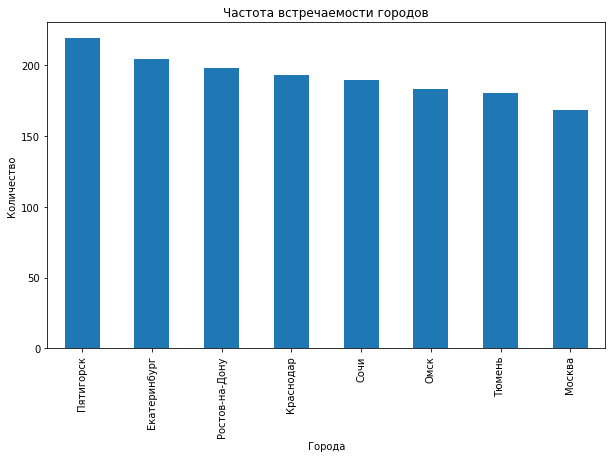

In [24]:
plt.figure(figsize=(10, 6))
df_users_go['city'].value_counts().plot(kind='bar')
plt.title('Частота встречаемости городов')
plt.xlabel('Города')
plt.ylabel('Количество')
plt.show()

Промежуточные выводы данные содержат информацию о пользователях 8 городов, больше всего количество пользователей в Пятигорске, а в Москве меньше всего. Но пользователи распределены более-менее равномерно без выбивающихся значений.

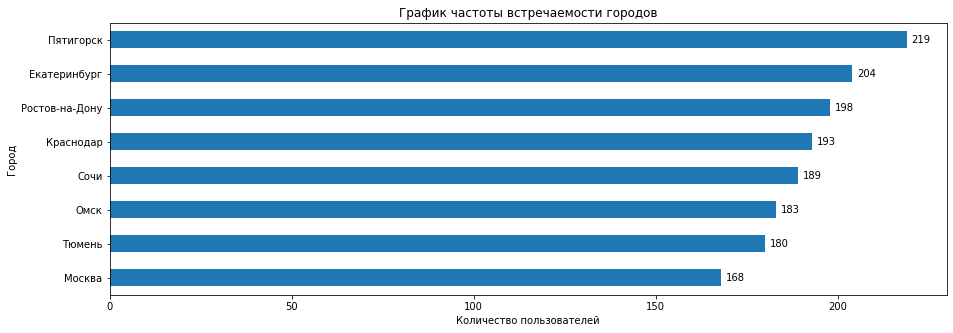

In [25]:
# Комментарий ревьюера
import matplotlib.pyplot as plt
import pandas as pd

# Создаем копию датасета, что бы не работать с исходным
tmp = df_users_go.copy()

# Построение горизонтальной диаграммы
ax = tmp['city'].value_counts(ascending=True).plot(
    kind='barh',
    figsize=(15, 5),
    title='График частоты встречаемости городов'
)

# Добавление значений рядом со столбцами
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width}',
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5, 0),
                textcoords='offset points')

# Добавление меток осей
plt.xlabel('Количество пользователей')
plt.ylabel('Город')

# Отображение графика
plt.show()

Соотношение пользователей с подпиской и без подписки. С подпиской должно быть меньше.

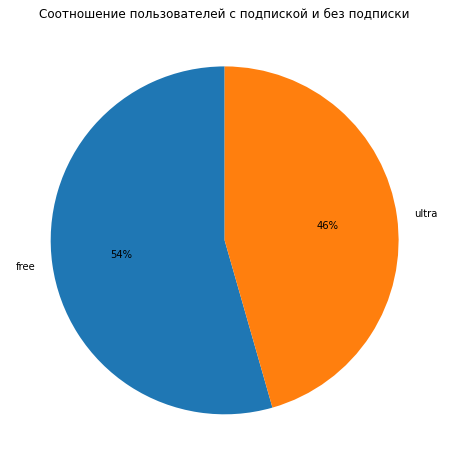

In [26]:
df_users_go_sub_count = df_users_go.pivot_table(index='subscription_type', values='user_id', aggfunc='count').reset_index()

plt.figure(figsize=(8, 8))
plt.pie(df_users_go_sub_count['user_id'], labels=df_users_go_sub_count['subscription_type'], startangle=90, autopct = "%.0f%%")
plt.title('Соотношение пользователей с подпиской и без подписки')
plt.show()

In [27]:
df_users_go_sub_count

,subscription_type,user_id
0,free,835
1,ultra,699


Пользователей c подпиской оказалось ненамного меньше.

Возраст пользователей

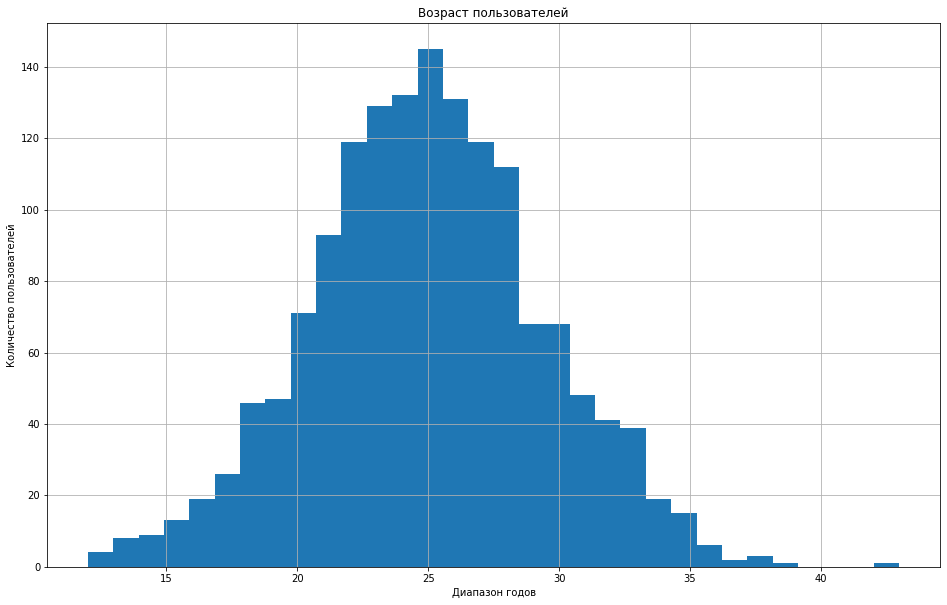

In [28]:
df_users_go['age'].plot(kind = 'hist', grid=True, figsize = (16,10), bins = 32)
plt.title('Возраст пользователей')
plt.xlabel('Диапазон годов')
plt.ylabel('Количество пользователей')
plt.show()

Возраст пользователей имеет нормальное (колоколоподобное) распределение.

In [29]:
df_users_go['age'].describe()

count    1534.000000
mean       24.903520
std         4.572367
min        12.000000
25%        22.000000
50%        25.000000
75%        28.000000
max        43.000000
Name: age, dtype: float64

Нет данных о пользователях младше 12 и старше 43. Основная часть пользователей приходится на 22-28 летних, среди которых преобладают 25летние пользователи. Это видно по медиане и по среднему арифметическому и по диаграмме. 

Попробую объединить два последних вывода о двух диагаммах в один.

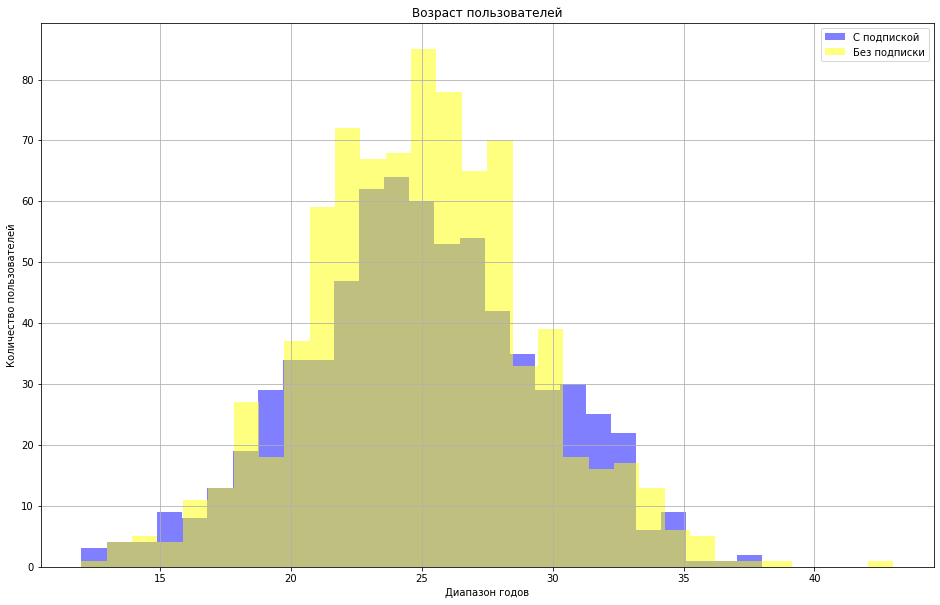

In [30]:
plt.figure(figsize=(16, 10))

plt.hist(df_users_go[df_users_go['subscription_type'] == 'ultra']['age'], 
         bins=27, alpha=0.5, label='С подпиской', color='blue')

plt.hist(df_users_go[df_users_go['subscription_type'] != 'ultra']['age'], 
         bins=32, alpha=0.5, label='Без подписки', color='yellow')

# Заголовок и метки осей
plt.title('Возраст пользователей')
plt.xlabel('Диапазон годов')
plt.ylabel('Количество пользователей')
plt.legend()


plt.grid(True)
plt.show()

Пользователи 30-35 лет охотнее приобретают подписку. Этим выводом можно пренебречь из-за малого количества этих самых пользователей. Но можно взлянуть на диаграмму и убедиться в преобладании пользователей без подписки. 

А так же в нормальном распределении двух групп пользователей.

Расстояние, которое пользователь преодолел за одну поездку

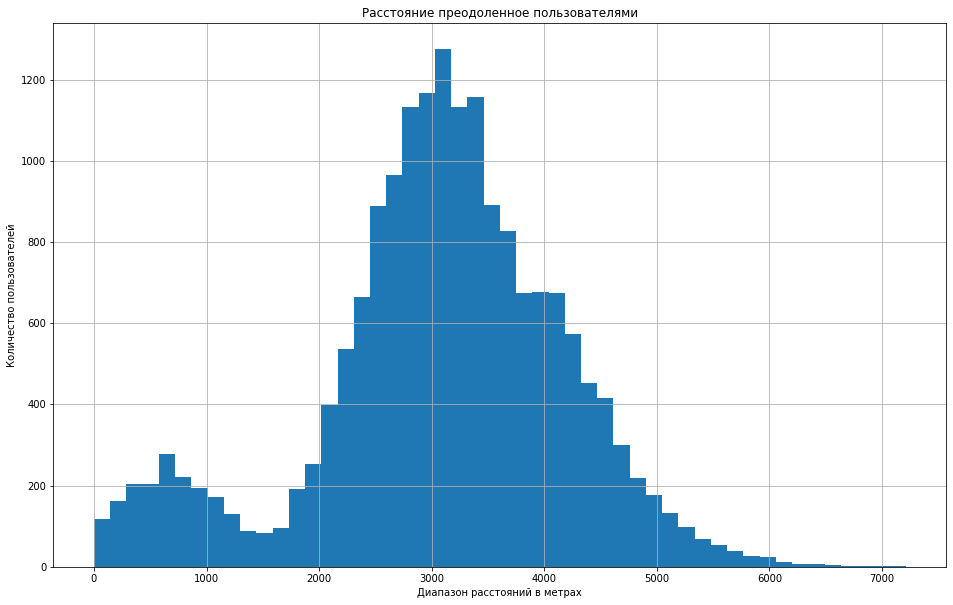

In [31]:
df_rides_go['distance'].plot(kind = 'hist', grid=True, figsize = (16,10), bins = 50)
plt.title('Расстояние преодоленное пользователями')
plt.xlabel('Диапазон расстояний в метрах')
plt.ylabel('Количество пользователей')
plt.show()

In [32]:
df_rides_go['distance'].describe()

count    18068.000000
mean      3070.659976
std       1116.831209
min          0.855683
25%       2543.226360
50%       3133.609994
75%       3776.222735
max       7211.007745
Name: distance, dtype: float64

Почти нормальное распределение, если не считать всплеска пользователей, которые часто проезжают от 500 до 1116 с пиком в 700 метров, создавая своё отдельное распределение. Если это не ошибка в данных, то это отдельная группа пользователей, которые пользуются самокатами что бы быстро доехать до какого-нибудь определенного места, которое находится не слишком далеко, но они торопятся.

продолжительность поездок

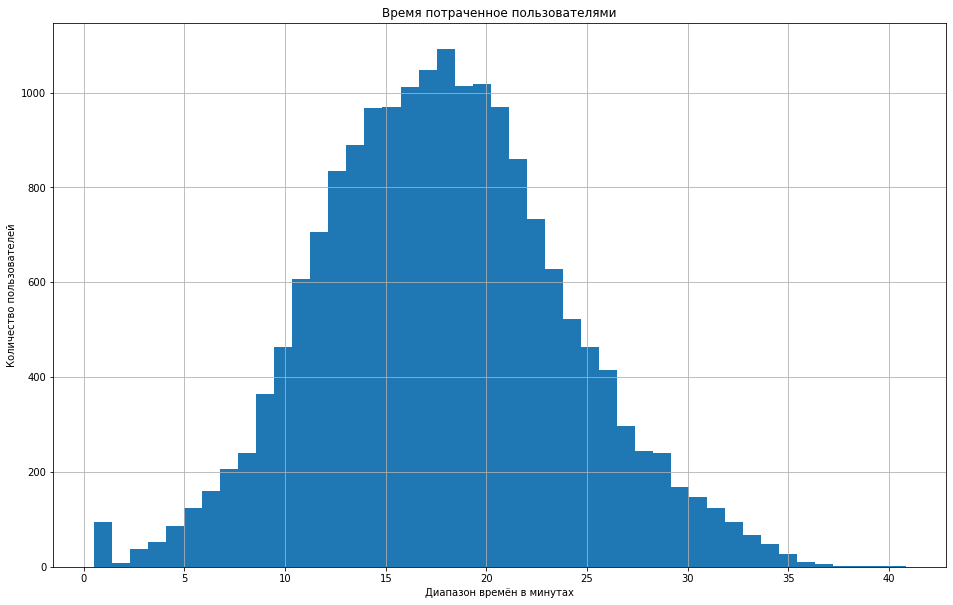

In [33]:
df_rides_go['duration'].plot(kind = 'hist', grid=True, figsize = (16,10), bins = 45)
plt.title('Время потраченное пользователями')
plt.xlabel('Диапазон времён в минутах')
plt.ylabel('Количество пользователей')
plt.show()

In [34]:
df_rides_go['duration'].describe()

count    18068.000000
mean        17.805011
std          6.091051
min          0.500000
25%         13.597563
50%         17.678395
75%         21.724800
max         40.823963
Name: duration, dtype: float64

Снова нормальное распределение. В среднем пользователи тратят на поездку 17 минут +-4минуты. 

А еще какой-то странный всплеск пользователей в начале, которые оплатили поездку на самокате, а потом передумали. Может из-за неисправности самоката или из-за погодных условий.

#### Шаг 4. Объединение данных

Объединим данные о пользователях, поездках и подписках в один датафрейм. У них есть общие столбцы: user_id и subscription_type.

In [35]:
df_go = df_users_go.copy() #копия на всякий случай
df_go = df_go.merge(df_rides_go, how = 'left', on = 'user_id' )
df_go = df_go.merge(df_subscriptions_go, how = 'left', on='subscription_type')
df_go.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 18068 entries, 0 to 18067
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            18068 non-null  int64         
 1   name               18068 non-null  object        
 2   age                18068 non-null  int64         
 3   city               18068 non-null  object        
 4   subscription_type  18068 non-null  object        
 5   distance           18068 non-null  float64       
 6   duration           18068 non-null  float64       
 7   date               18068 non-null  datetime64[ns]
 8   month              18068 non-null  int64         
 9   minute_price       18068 non-null  int64         
 10  start_ride_price   18068 non-null  int64         
 11  subscription_fee   18068 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(6), object(3)
memory usage: 1.8+ MB


Прекрасно.

In [36]:
df_go_subs_free = df_go[df_go['subscription_type'] != 'ultra']
df_go_subs_ultra = df_go[df_go['subscription_type'] != 'free']

In [37]:
df_go_subs_free.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 11568 entries, 6500 to 18067
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            11568 non-null  int64         
 1   name               11568 non-null  object        
 2   age                11568 non-null  int64         
 3   city               11568 non-null  object        
 4   subscription_type  11568 non-null  object        
 5   distance           11568 non-null  float64       
 6   duration           11568 non-null  float64       
 7   date               11568 non-null  datetime64[ns]
 8   month              11568 non-null  int64         
 9   minute_price       11568 non-null  int64         
 10  start_ride_price   11568 non-null  int64         
 11  subscription_fee   11568 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(6), object(3)
memory usage: 1.1+ MB


In [38]:
df_go_subs_ultra.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 6500 entries, 0 to 6499
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            6500 non-null   int64         
 1   name               6500 non-null   object        
 2   age                6500 non-null   int64         
 3   city               6500 non-null   object        
 4   subscription_type  6500 non-null   object        
 5   distance           6500 non-null   float64       
 6   duration           6500 non-null   float64       
 7   date               6500 non-null   datetime64[ns]
 8   month              6500 non-null   int64         
 9   minute_price       6500 non-null   int64         
 10  start_ride_price   6500 non-null   int64         
 11  subscription_fee   6500 non-null   int64         
dtypes: datetime64[ns](1), float64(2), int64(6), object(3)
memory usage: 660.2+ KB


In [39]:
df_go_subs_free.head()

,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
6500,700,Айдар,22,Омск,free,2515.690719,14.944286,2021-01-02,1,8,50,0
6501,700,Айдар,22,Омск,free,846.932642,16.234663,2021-02-01,2,8,50,0
6502,700,Айдар,22,Омск,free,4004.434142,20.016628,2021-02-04,2,8,50,0
6503,700,Айдар,22,Омск,free,1205.911290,9.782872,2021-02-10,2,8,50,0
6504,700,Айдар,22,Омск,free,3047.379435,17.427673,2021-02-14,2,8,50,0


In [40]:
df_go_subs_ultra.head()

,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.919140,25.599769,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.592153,15.816871,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,ultra,754.159807,6.232113,2021-04-20,4,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.783254,18.511000,2021-08-11,8,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.687306,26.265803,2021-08-28,8,6,0,199


Визуализируем информацию о расстоянии и времени поездок для пользователей обеих категорий. Я ранее начал делать что-то подобное, но выводов из этого не сделал. С новыми датафреймами я смогу сделать новые выводы.

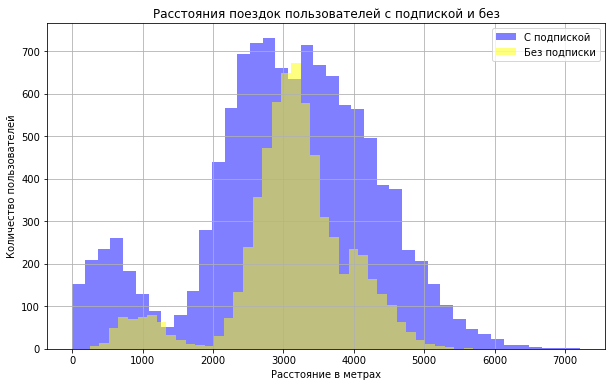

In [41]:
plt.figure(figsize=(10, 6))

plt.hist(df_go_subs_free[df_go_subs_free['subscription_type'] == 'free']['distance'], 
         bins=40, alpha=0.5, label='С подпиской', color='blue')

plt.hist(df_go_subs_ultra[df_go_subs_ultra['subscription_type'] == 'ultra']['distance'], 
         bins=40, alpha=0.5, label='Без подписки', color='yellow')

# Заголовок и метки осей
plt.title('Расстояния поездок пользователей с подпиской и без')
plt.xlabel('Расстояние в метрах')
plt.ylabel('Количество пользователей')
plt.legend()


plt.grid(True)
plt.show()

Ничего примечательного.

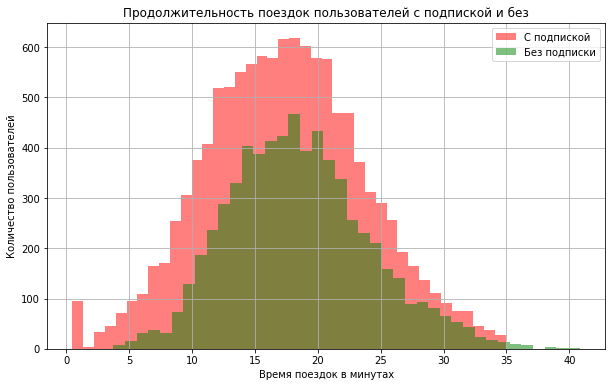

In [42]:
plt.figure(figsize=(10, 6))

plt.hist(df_go_subs_free[df_go_subs_free['subscription_type'] == 'free']['duration'], 
         bins=40, alpha=0.5, label='С подпиской', color='red')

plt.hist(df_go_subs_ultra[df_go_subs_ultra['subscription_type'] == 'ultra']['duration'], 
         bins=40, alpha=0.5, label='Без подписки', color='green')

# Заголовок и метки осей
plt.title('Продолжительность поездок пользователей с подпиской и без')
plt.xlabel('Время поездок в минутах')
plt.ylabel('Количество пользователей')
plt.legend()


plt.grid(True)
plt.show()

Тот всплеск в начале,пользователи которые взяли самокат, но не катались на нем продолжительное время владели подпиской. У тех, кто не владеет подпиской ultra такой проблемы нет. Я не знаю что это может быть.

Промежуточный вывод. Проблем с данными не наблюдается. Но и выводов пока сделать нельзя.

#### Шаг 5. Подсчёт выручки

Сейчас мы создадим датафрейм с агрегированными данными о поездках на основе датафрейма с объединёнными данными из предыдущего: найдем суммарное расстояние, количество поездок и суммарное время для каждого пользователя за каждый месяц.


In [43]:
df_go_duration_rounding = df_go.copy() #копия датасета, которую мы будем округлять

In [44]:
df_go_duration_rounding['duration'] = np.ceil(df_go_duration_rounding['duration'])
df_go_duration_rounding['duration'] = df_go_duration_rounding['duration'].astype('int') #округлили

In [45]:
df_go_duration_rounding.head()

,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.919140,26,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.592153,16,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,ultra,754.159807,7,2021-04-20,4,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.783254,19,2021-08-11,8,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.687306,27,2021-08-28,8,6,0,199


In [46]:
df_go_agr = df_go_duration_rounding.pivot_table(index= ['user_id', 'month'], values = ['distance', 'duration'], aggfunc = ['count', 'sum'])

df_go_agr.head()

count                   sum         
              distance duration     distance duration
user_id month                                        
1       1            2        2  7027.511294       42
        4            1        1   754.159807        7
        8            2        2  6723.470560       46
        10           2        2  5809.911100       32
        11           3        3  7003.499363       56

In [47]:
df_go_agr.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 11331 entries, (1, 1) to (1534, 12)
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (count, distance)  11331 non-null  int64  
 1   (count, duration)  11331 non-null  int64  
 2   (sum, distance)    11331 non-null  float64
 3   (sum, duration)    11331 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 399.5 KB


In [48]:
df_go_agr.isnull().sum()

count  distance    0
       duration    0
sum    distance    0
       duration    0
dtype: int64

In [49]:
df_go_agr = df_go_agr.drop(columns=[('count', 'distance')])
df_go_agr.columns = df_go_agr.columns.droplevel(0)
df_go_agr = df_go_agr.reset_index()


df_go_agr.columns.values[2] = 'count_ride'

df_go_agr.head()

,user_id,month,count_ride,distance,duration
0,1,1,2,7027.511294,42
1,1,4,1,754.159807,7
2,1,8,2,6723.470560,46
3,1,10,2,5809.911100,32
4,1,11,3,7003.499363,56


В колонке user_id находится уникальный идентификатор пользователя, а в колонке month находится счетчик месяцев, во время которых он пользовался самокатами. 
Количество использований самокатов в определенный месяц для каждого пользователя находится в count_ride. 
В distance и duration находятся суммарное расстояние пройденное пользователем за соответствующий месяц и, соответственно, суммарное время поездки на самокате за этот месяц.

Номер месяца начинается с января.

В этот же датафрейм добавим столбец с помесячной выручкой, которую принёс каждый пользователь. 
Для этого обратитимся к информации об условиях оплаты для подписчиков и тех, у кого нет подписки.

Продолжительность каждой поездки в каждой строке исходного датафрейма для подсчёта стоимости округлим до следующего целого числа. 

In [50]:
df_go_agr = df_go_agr.merge(df_users_go, how='left', on='user_id')
df_go_agr = df_go_agr.merge(df_subscriptions_go, how = 'left', on='subscription_type')

#df_go_agr['duration'] = np.ceil(df_go_agr['duration']) 
#df_go_agr['duration'] = df_go_agr['duration'].astype('int')

df_go_agr

,user_id,month,count_ride,distance,duration,name,age,city,subscription_type,minute_price,start_ride_price,subscription_fee
0,1,1,2,7027.511294,42,Кира,22,Тюмень,ultra,6,0,199
1,1,4,1,754.159807,7,Кира,22,Тюмень,ultra,6,0,199
2,1,8,2,6723.470560,46,Кира,22,Тюмень,ultra,6,0,199
3,1,10,2,5809.911100,32,Кира,22,Тюмень,ultra,6,0,199
4,1,11,3,7003.499363,56,Кира,22,Тюмень,ultra,6,0,199
...,...,...,...,...,...,...,...,...,...,...,...,...
11326,1534,6,2,3409.468534,26,Альберт,25,Краснодар,free,8,50,0
11327,1534,8,2,7622.453034,48,Альберт,25,Краснодар,free,8,50,0
11328,1534,9,1,4928.173852,23,Альберт,25,Краснодар,free,8,50,0
11329,1534,11,4,13350.015305,78,Альберт,25,Краснодар,free,8,50,0


Помесячная выручка считается по формуле: 
стоимость старта поездки × количество поездок + стоимость одной минуты поездки × общая продолжительность всех поездок в минутах + стоимость подписки.

In [51]:
df_go_agr['revenue'] = (df_go_agr['start_ride_price'] * df_go_agr['count_ride'] +
                 df_go_agr['minute_price'] * df_go_agr['duration'] +
                 df_go_agr['subscription_fee'])
df_go_agr

,user_id,month,count_ride,distance,duration,name,age,city,subscription_type,minute_price,start_ride_price,subscription_fee,revenue
0,1,1,2,7027.511294,42,Кира,22,Тюмень,ultra,6,0,199,451
1,1,4,1,754.159807,7,Кира,22,Тюмень,ultra,6,0,199,241
2,1,8,2,6723.470560,46,Кира,22,Тюмень,ultra,6,0,199,475
3,1,10,2,5809.911100,32,Кира,22,Тюмень,ultra,6,0,199,391
4,1,11,3,7003.499363,56,Кира,22,Тюмень,ultra,6,0,199,535
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11326,1534,6,2,3409.468534,26,Альберт,25,Краснодар,free,8,50,0,308
11327,1534,8,2,7622.453034,48,Альберт,25,Краснодар,free,8,50,0,484
11328,1534,9,1,4928.173852,23,Альберт,25,Краснодар,free,8,50,0,234
11329,1534,11,4,13350.015305,78,Альберт,25,Краснодар,free,8,50,0,824


In [52]:
# Комментарий ревьюера
# Контроль суммы выручки
tmp, col_rev = df_go_agr.copy(), 'revenue'
print("Правильное значение суммы выручки 3878641, сумма выручки расчитанная в таблице:", tmp[col_rev].sum())

Правильное значение суммы выручки 3878641, сумма выручки расчитанная в таблице: 3878641


Промежуточный вывод. Расчет выручки был сделан (не мной), и мы можем видеть, что сумма выручки равна 3878641.

Так же мы высчитали помесячную выручку от каждого пользователя и теперь можем анализировать гипотезы, связанные с подписками, доходами, временем и расстояниями.

#### Шаг 6. Проверка гипотез

Продакт-менеджеры сервиса хотят увеличить количество пользователей с подпиской. 
Для этого они будут проводить различные акции, но сначала нужно выяснить несколько важных моментов.

Важно понять, тратят ли пользователи с подпиской больше времени на поездки? Если да, то пользователи с подпиской могут быть «выгоднее» для компании. 

Проверим гипотезу. Используем исходные данные о продолжительности каждой сессии — отдельно для подписчиков и тех, у кого нет подписки.

Мы уже ранее видели диаграмму времени поездки пользователей с подпиской и без. И там видно то, что гипотеза не подтверждается. Но пользователи с подпиской и без приносят разные доходы. Что бы окончательно разобраться в этом я использую нехитрые подсчеты.
Сформулируем гипотезу

H0​(нулевая гипотеза): Средняя продолжительность поездки пользователей с подпиской равна средней продолжительности поездки пользователей без подписки.

H1​ (альтернативная гипотеза): Средняя продолжительность поездки пользователей с подпиской больше средней продолжительности поездки пользователей без подписки.

Эти гипотезы задают основу для статистического тестирования. Если будут получены результаты, указывающие на то, что средняя продолжительность поездок пользователей с подпиской значительно больше, чем у пользователей без подписки, это может подтвердить, что подписчики действительно тратят больше времени на поездки, и, следовательно, могут быть "выгоднее" для компании.

In [53]:
# Проведение t-теста
t_stat, p_value = stats.ttest_ind(df_go_subs_ultra['duration'], df_go_subs_free['duration'], alternative='greater')

# Вывод результатов
print(f'T-статистика: {t_stat}')
print(f'P-значение: {p_value}')

# Интерпретация результатов
alpha = 0.05  # уровень значимости
if p_value < alpha:
    print("Отвергаем нулевую гипотезу: пользователи с подпиской тратят больше времени.")
else:
    print("Не удалось отвергнуть нулевую гипотезу: нет достаточных доказательств, что пользователи с подпиской тратят больше времени.")

T-статистика: 12.241203729044017
P-значение: 1.2804098316645618e-34
Отвергаем нулевую гипотезу: пользователи с подпиской тратят больше времени.


Мы применили одностороннюю гипотезу (ведь им важно узнать, тратят ли они больше времени)
Вывод: пользователи с подпиской тратят больше времени и могут быть "выгоднее" для компании.

In [54]:
df_go_subs_ultra['duration'].mean()

18.54198516280583

In [55]:
df_go_subs_free['duration'].mean()

17.39090929866399

Расстояние одной поездки в 3130 метров — оптимальное с точки зрения износа самоката. Можно ли сказать, что среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает 3130 метров?
Проверим гипотезу и сделайте выводы.

Формулировка гипотез:

Нулевая гипотеза (H0): Среднее расстояние поездок пользователей с подпиской равно или меньше 3130 метров.

Альтернативная гипотеза (H1): Среднее расстояние поездок пользователей с подпиской превышает 3130 метров.

In [56]:

#t_stat, p_value = stats.ttest_1samp(df_go_subs_ultra['distance'], 3130)
# Вывод результатов 
#if p_value < alpha:
    #print("Отвергаем нулевую гипотезу: среднее расстояние поездок пользователей с подпиской превышает 3130 метров.")
#else:
   # print("Не удалось отвергнуть нулевую гипотезу: среднее расстояние поездок пользователей с подпиской не превышает 3130 метров.")
    
    
    
# Проведение одностороннего t-теста     
t_stat, p_value = stats.ttest_1samp(df_go_subs_ultra['distance'], 3130, alternative='greater') #ранее alternative='two-sided', 'less' 

print(f'P-значение: {p_value}')    

# Уровень значимости
alpha = 0.05
if p_value < alpha:
    print("Отвергаем нулевую гипотезу: среднее расстояние поездок пользователей с подпиской превышает 3130 метров.")
else:
    print("Не удалось отвергнуть нулевую гипотезу: среднее расстояние поездок пользователей с подпиской не превышает 3130 метров.")

P-значение: 0.9195368847849785
Не удалось отвергнуть нулевую гипотезу: среднее расстояние поездок пользователей с подпиской не превышает 3130 метров.


In [57]:
df_go_subs_ultra['distance'].mean()

3115.4453880370247

Гипотеза по формулировке похожа на предыдущую. Вывод: самокаты будут оптимально изнашиваться.

Проверим гипотезу о том, будет ли помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки.

Формулировка гипотез:

Нулевая гипотеза (H0): Средняя помесячная выручка пользователей с подпиской равна или меньше, чем средняя помесячная выручка пользователей без подписки.

Альтернативная гипотеза (H1): Средняя помесячная выручка пользователей с подпиской выше, чем средняя помесячная выручка пользователей без подписки.

In [58]:
#monthly_revenue = df_go_agr.groupby(['month', 'subscription_type'])['revenue'].sum().reset_index()
#monthly_revenue

In [59]:
# создадим две выборки с посчитанной помесячной выручкой
df_go_agr_ultra = df_go_agr[df_go_agr['subscription_type'] == 'ultra']
df_go_agr_free = df_go_agr[df_go_agr['subscription_type'] == 'free']

results = stats.ttest_ind(df_go_agr_ultra['revenue']
                                  , df_go_agr_free['revenue']
                                  , alternative='greater')
alpha = 0.05
print(f'T-статистика: {t_stat}')
print(f'P-значение: {p_value}')

if p_value < alpha:
    print("Отвергаем нулевую гипотезу: помесячная выручка пользователей с подпиской выше, чем у пользователей без подписки.")
else:
    print("Не удалось отвергнуть нулевую гипотезу: помесячная выручка пользователей с подпиской не выше, чем у пользователей без подписки.")

T-статистика: -1.402123166869486
P-значение: 0.9195368847849785
Не удалось отвергнуть нулевую гипотезу: помесячная выручка пользователей с подпиской не выше, чем у пользователей без подписки.


In [60]:
#t_stat, p_value = stats.ttest_ind(monthly_revenue[monthly_revenue['subscription_type'] == 'ultra']['revenue']
                                 # , monthly_revenue[monthly_revenue['subscription_type'] == 'free']['revenue']
                                 # , alternative='greater')
#alpha = 0.05

# Вывод результатов
#print(f'T-статистика: {t_stat}')
#print(f'P-значение: {p_value}')

# Проверка гипотезы
#if p_value < alpha:
   # print("Отвергаем нулевую гипотезу: помесячная выручка пользователей с подпиской выше, чем у пользователей без подписки.")
#else:
   # print("Не удалось отвергнуть нулевую гипотезу: помесячная выручка пользователей с подпиской не выше, чем у пользователей без подписки.")

Увы, но пользователи без подписок приносят основной доход.

Помесячная выручка пользователей с подпиской не выше, чем у пользователей без подписки.

In [61]:
df_go_agr_ultra.groupby('subscription_type')['revenue'].sum().reset_index()


,subscription_type,revenue
0,ultra,1644537


In [62]:
df_go_agr_free.groupby('subscription_type')['revenue'].sum().reset_index()

,subscription_type,revenue
0,free,2234104


Представим такую ситуацию: техническая команда сервиса обновила сервера, с которыми взаимодействует мобильное приложение. Она надеется, что из-за этого количество обращений в техподдержку значимо снизилось. Некоторый файл содержит для каждого пользователя данные о количестве обращений до обновления и после него. Какой тест вам понадобился бы для проверки этой гипотезы?

парный t-тест.
Я бы передал туда два связанных набора данных (обращения до и после обновления) для каждого пользователя и таким образом понял бы. Снизилось или не снизилось кол-во обращений.

Нулевая гипотеза (H0): Среднее количество обращений пользователей в техподдержку после обновления не меньше, чем до обновления (т.е. нет значительного снижения).

Альтернативная гипотеза (H1): Среднее количество обращений пользователей в техподдержку после обновления меньше, чем до обновления (т.е. произошло значительное снижение).

Финальный вывод


средний возраст пользователя сервиса - 25 лет
Это были отличные данные без пропусков, ошибок, выбросов итд. Промежуточные выводы данные содержат информацию о пользователях 8 городов, больше всего количество пользователей в Пятигорске, а в Москве меньше всего. Среднее расстояние большинства поездок - 3 километра. Так же упоминуть стоит отдельную группу пользователей с небольшим интервалом поездок в 700 м.
пользователей сервиса аренды самокатов без подписки больше чем пользователей с подпиской.
Пользователей без подписок больше. И катаются они больше. И дохода приносят в общей массе свой больше.